# Section 4 — Official-sector data: who holds it, how it trades, how it issues

Thin driver notebook: all logic lives in `src/official/`. Two sources are stubbed rather than faked — see each module's docstring and `docs/excluded_sources.md`:

- **FFIEC bank call reports**: an ASP.NET WebForms postback, and Call Report schedules don't isolate CLO holdings as a distinct line item anyway.
- **SIFMA issuance statistics**: the download sits behind a HubSpot lead-gen form, not a direct file.

The CLO holder-composition chart is built from a single **TO-VERIFY** citation (a Fed FEDS Note, Dec 2018) — not a live series. Everything else (FRED macro series, FINRA/ICE TRACE-sourced CLO pricing) is live, real, and re-scraped each run.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

from IPython.display import Image, display

from src.official import (
    scrape_efa, scrape_ffiec, scrape_trace, scrape_sifma, scrape_fred,
    analysis_holders, analysis_banks, analysis_liquidity, analysis_issuance,
    viz_holders, viz_liquidity, viz_issuance,
)

/Users/zinuoshi/clo-atlas/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Scrape (raw -> interim)

In [2]:
RUN_SCRAPE = False
if RUN_SCRAPE:
    scrape_efa.run()
    scrape_ffiec.run()
    scrape_trace.run()
    scrape_sifma.run()
    scrape_fred.run()

## Analysis (interim -> final)

In [3]:
holders = analysis_holders.run()
banks = analysis_banks.run()
liquidity = analysis_liquidity.run()
issuance = analysis_issuance.run()

scrape_ffiec.py is stubbed — FFIEC bulk Call Report data requires replicating an ASP.NET WebForms postback and doesn't isolate CLO holdings as a distinct line item even once fetched. See docs/excluded_sources.md and this module's docstring.


no FFIEC data available; top_bank_holders is empty (see scrape_ffiec.py docstring)


scrape_sifma.py is stubbed — SIFMA's issuance-statistics download sits behind a HubSpot lead-gen form, not a direct file. See docs/excluded_sources.md.


no SIFMA issuance data available; issuance_cycle is empty (see scrape_sifma.py docstring)


## Viz (final -> figures/)

no issuance data available (SIFMA gated — see docs/excluded_sources.md); skipping viz_issuance_by_type


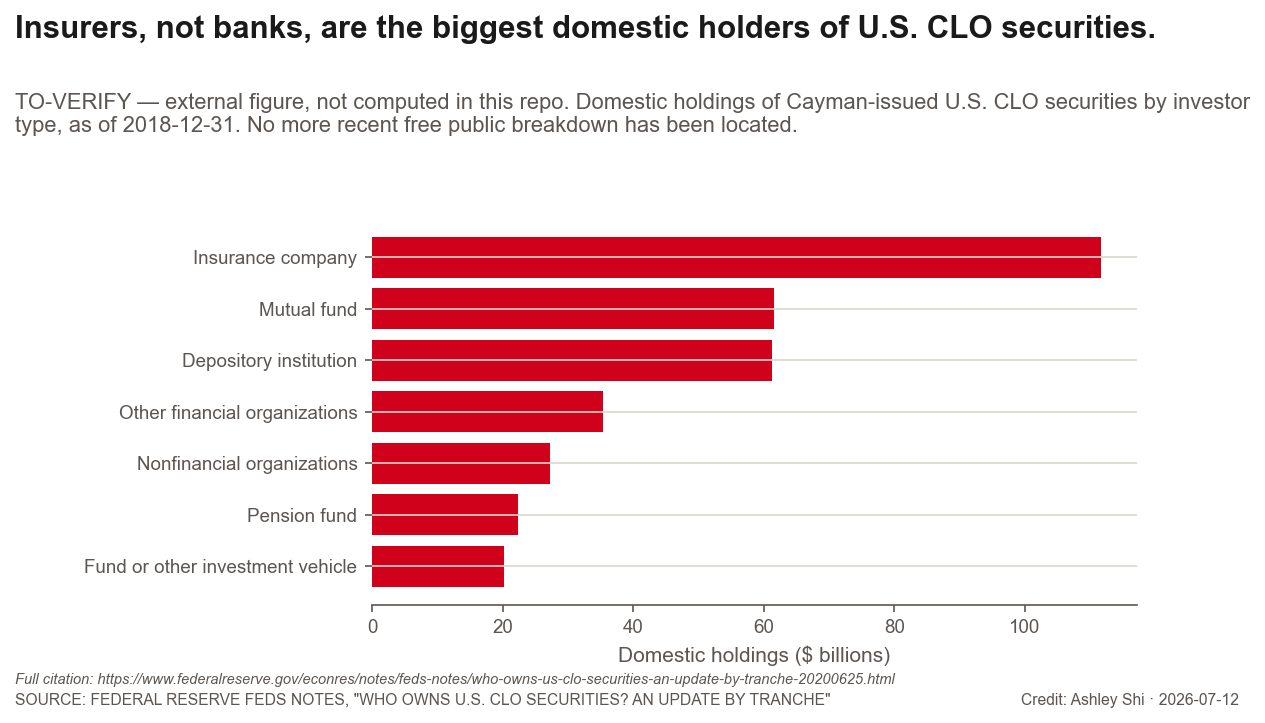

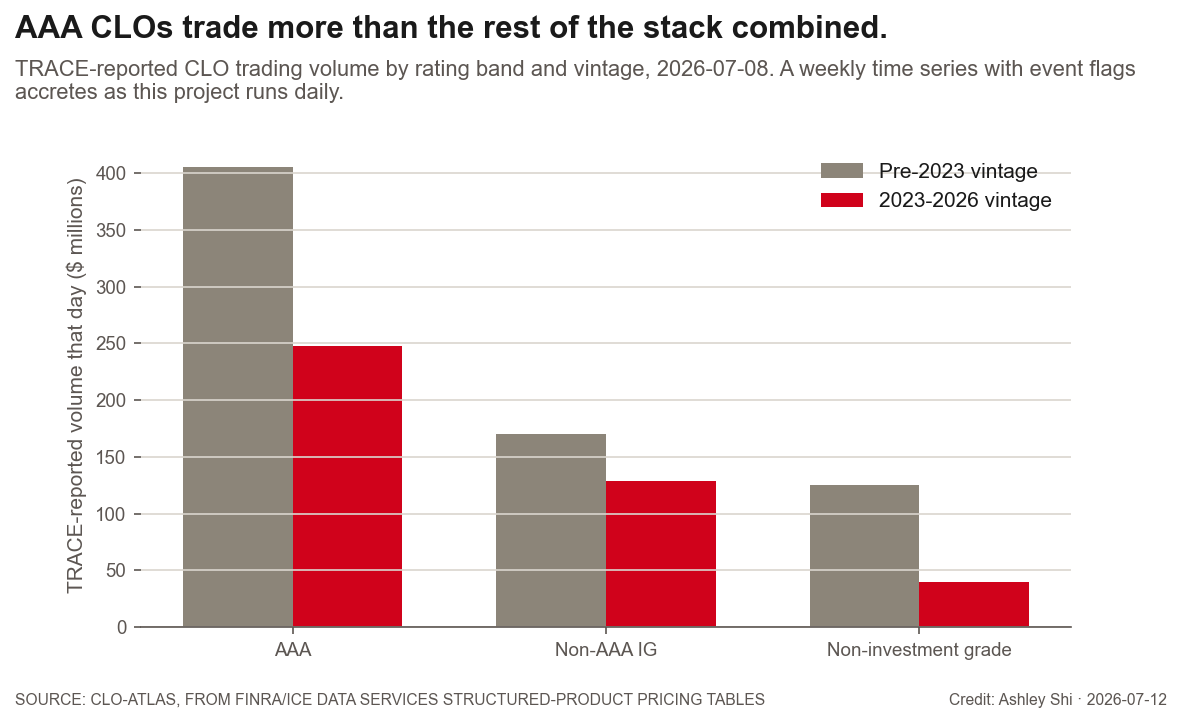

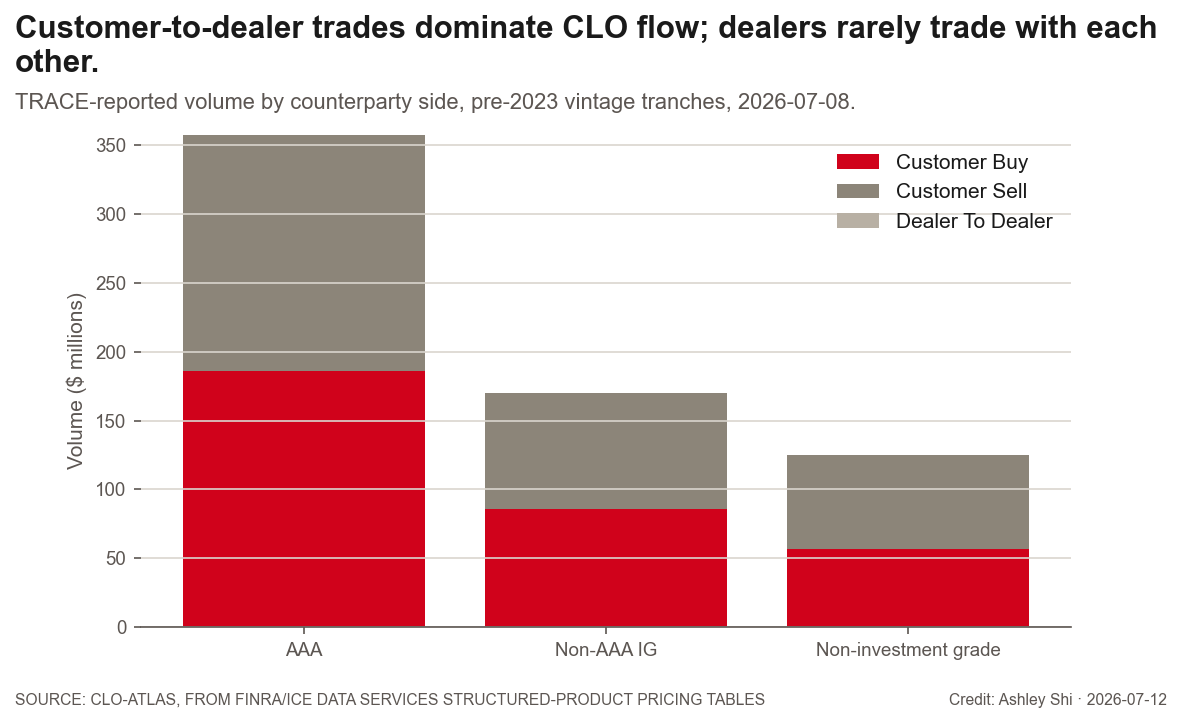

In [4]:
viz_holders.run()
viz_liquidity.run()
viz_issuance.run()

## Exhibits

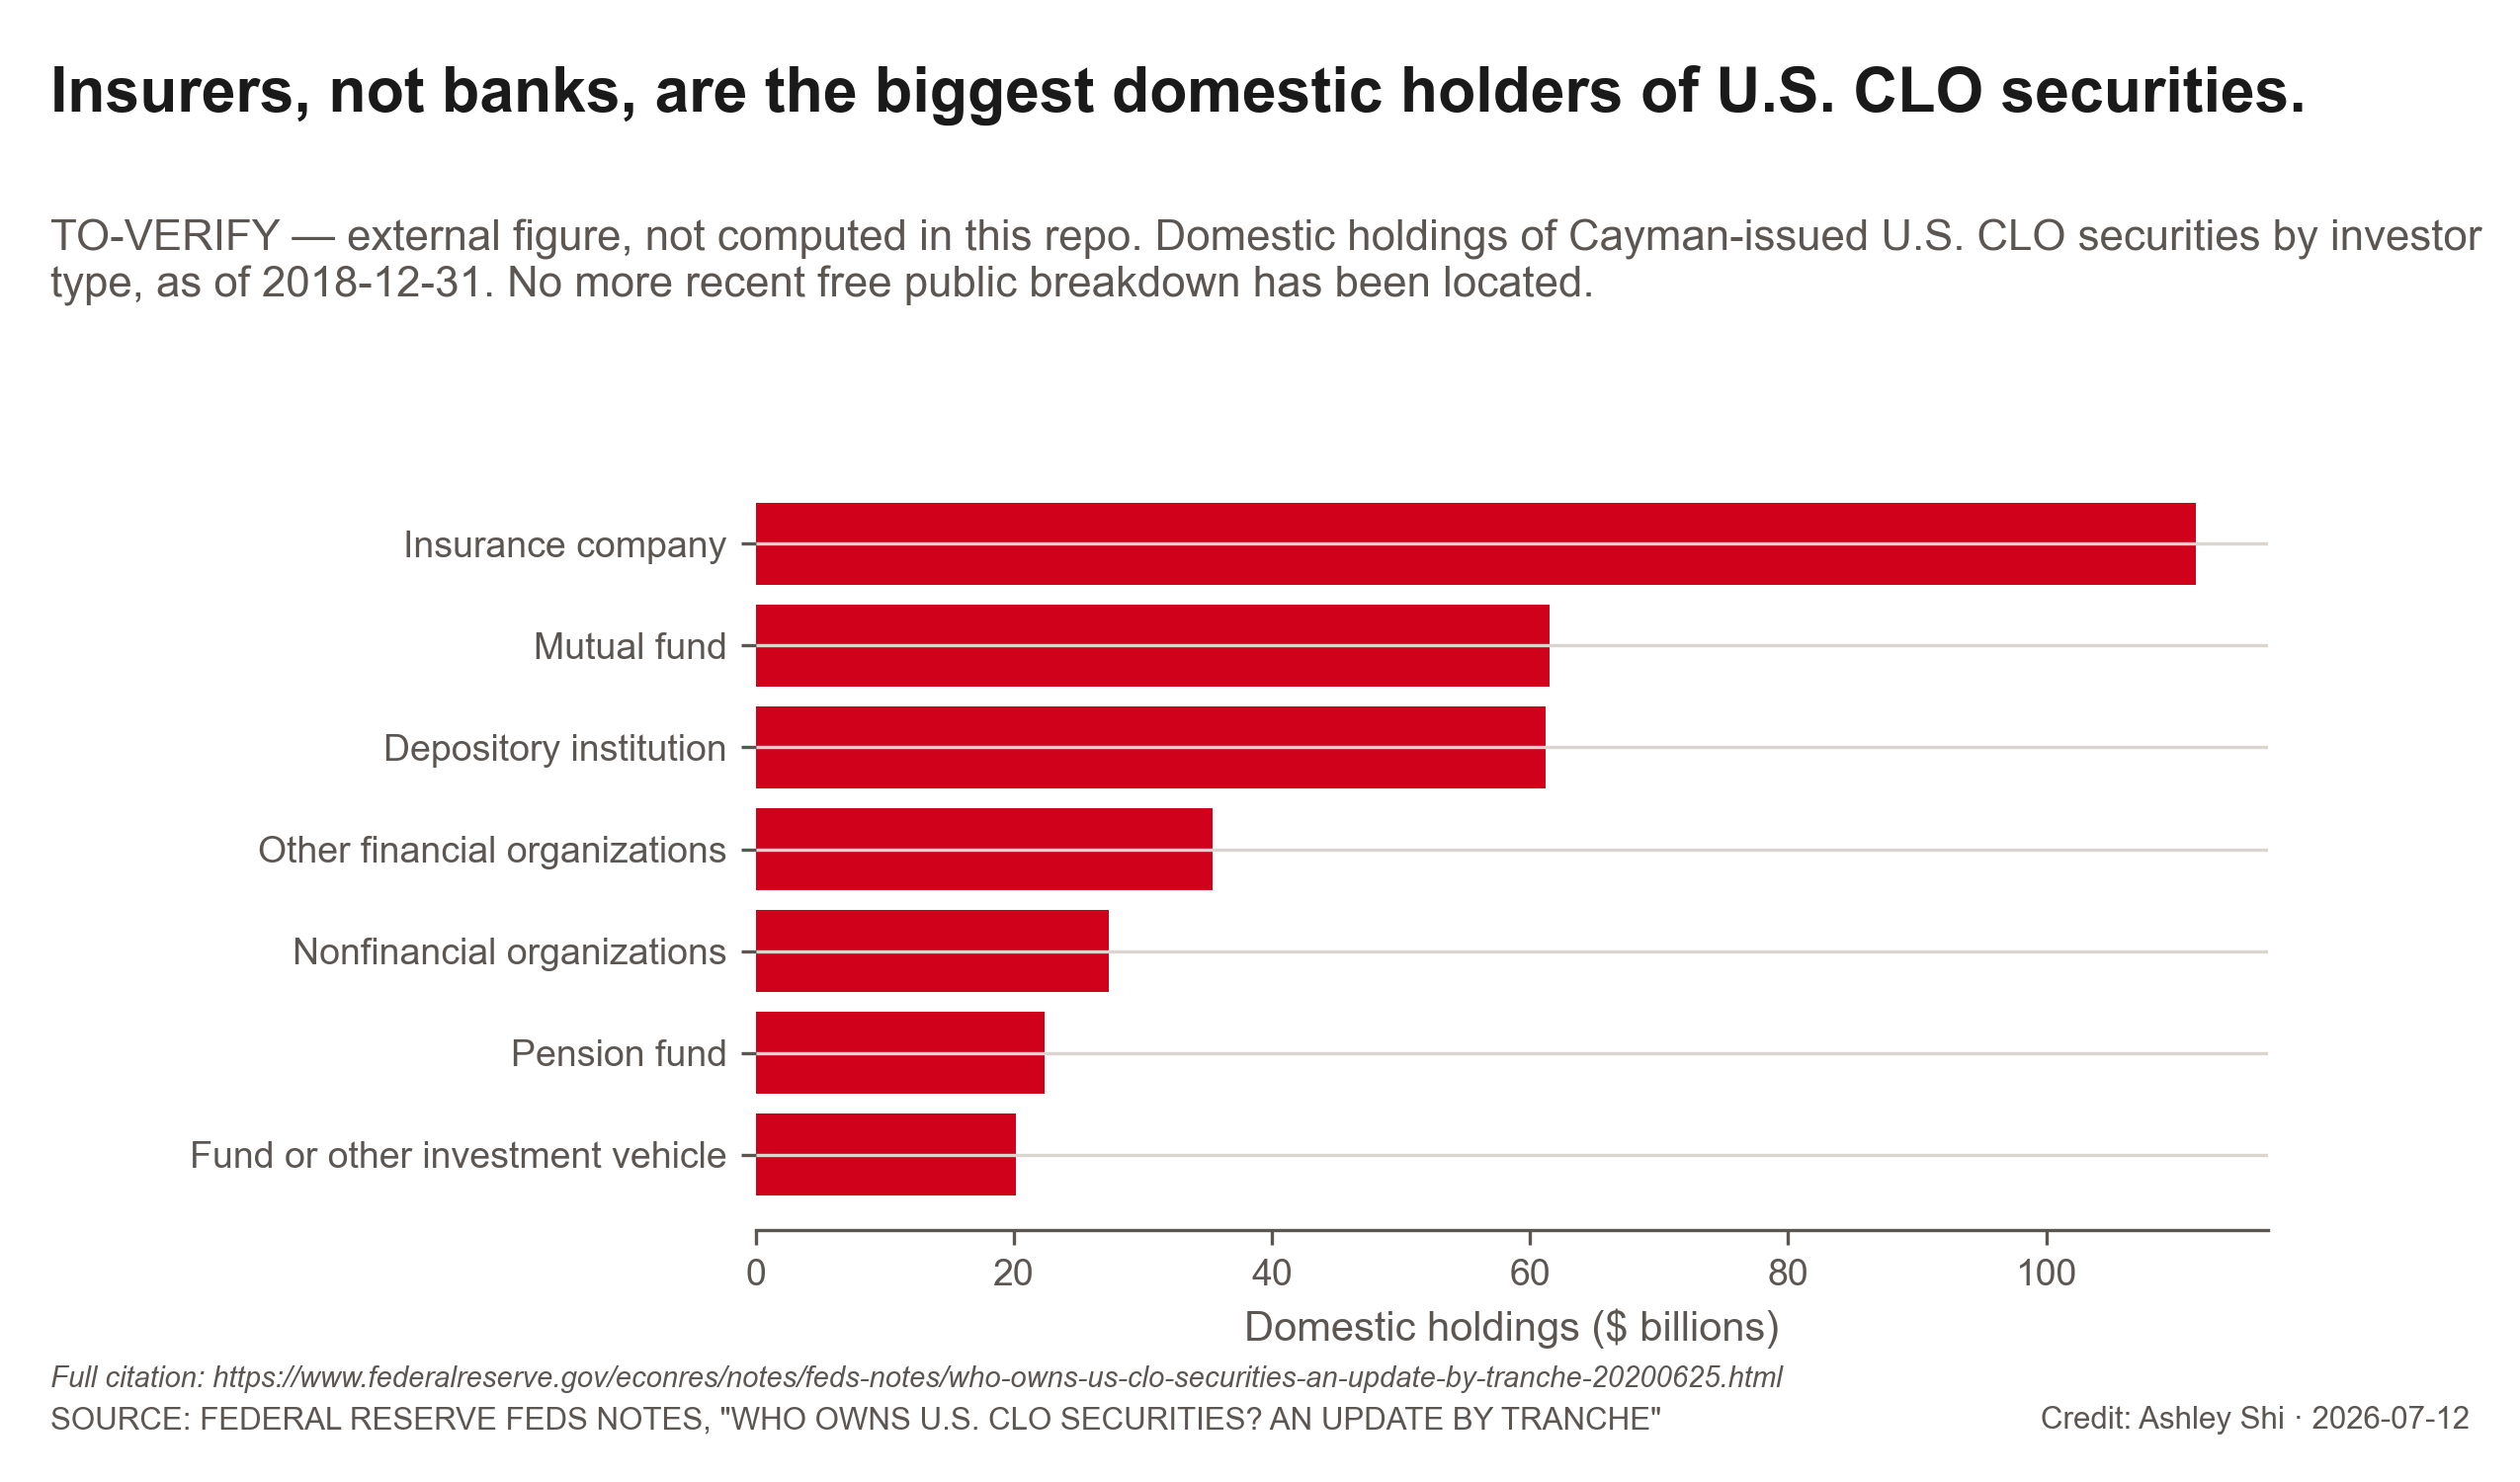

In [5]:
name = "viz_holder_composition"
path = pathlib.Path("../figures") / f"{name}.png"
if path.exists():
    display(Image(filename=str(path)))
else:
    print(f"[skipped — not generated this run] {name}")

**TO-VERIFY** — built from a single Federal Reserve FEDS Note, “Who Owns U.S. CLO Securities? An Update by Tranche” (June 2020, reporting a Dec-2018 snapshot), hand-cited in `config.FED_CLO_HOLDER_CITATION` rather than live-scraped — it's the most recent free, non-paywalled sector breakdown this project could locate, and no live series exists to update it.

The horizontal bars rank seven investor types by domestic dollar holdings of Cayman-issued U.S. CLO securities: insurance companies lead at $111.6bn, ahead of mutual funds ($61.5bn) and depository institutions ($61.2bn), with pension funds and other financial/nonfinancial organizations trailing.

For the “who owns this asset class” question, it's the single most important structural fact in this section: CLOs are not primarily a bank-balance-sheet product the way 2008-era CDOs are remembered — insurers, buying CLO paper as long-duration, capital-efficient credit exposure, hold almost twice what depository institutions do.

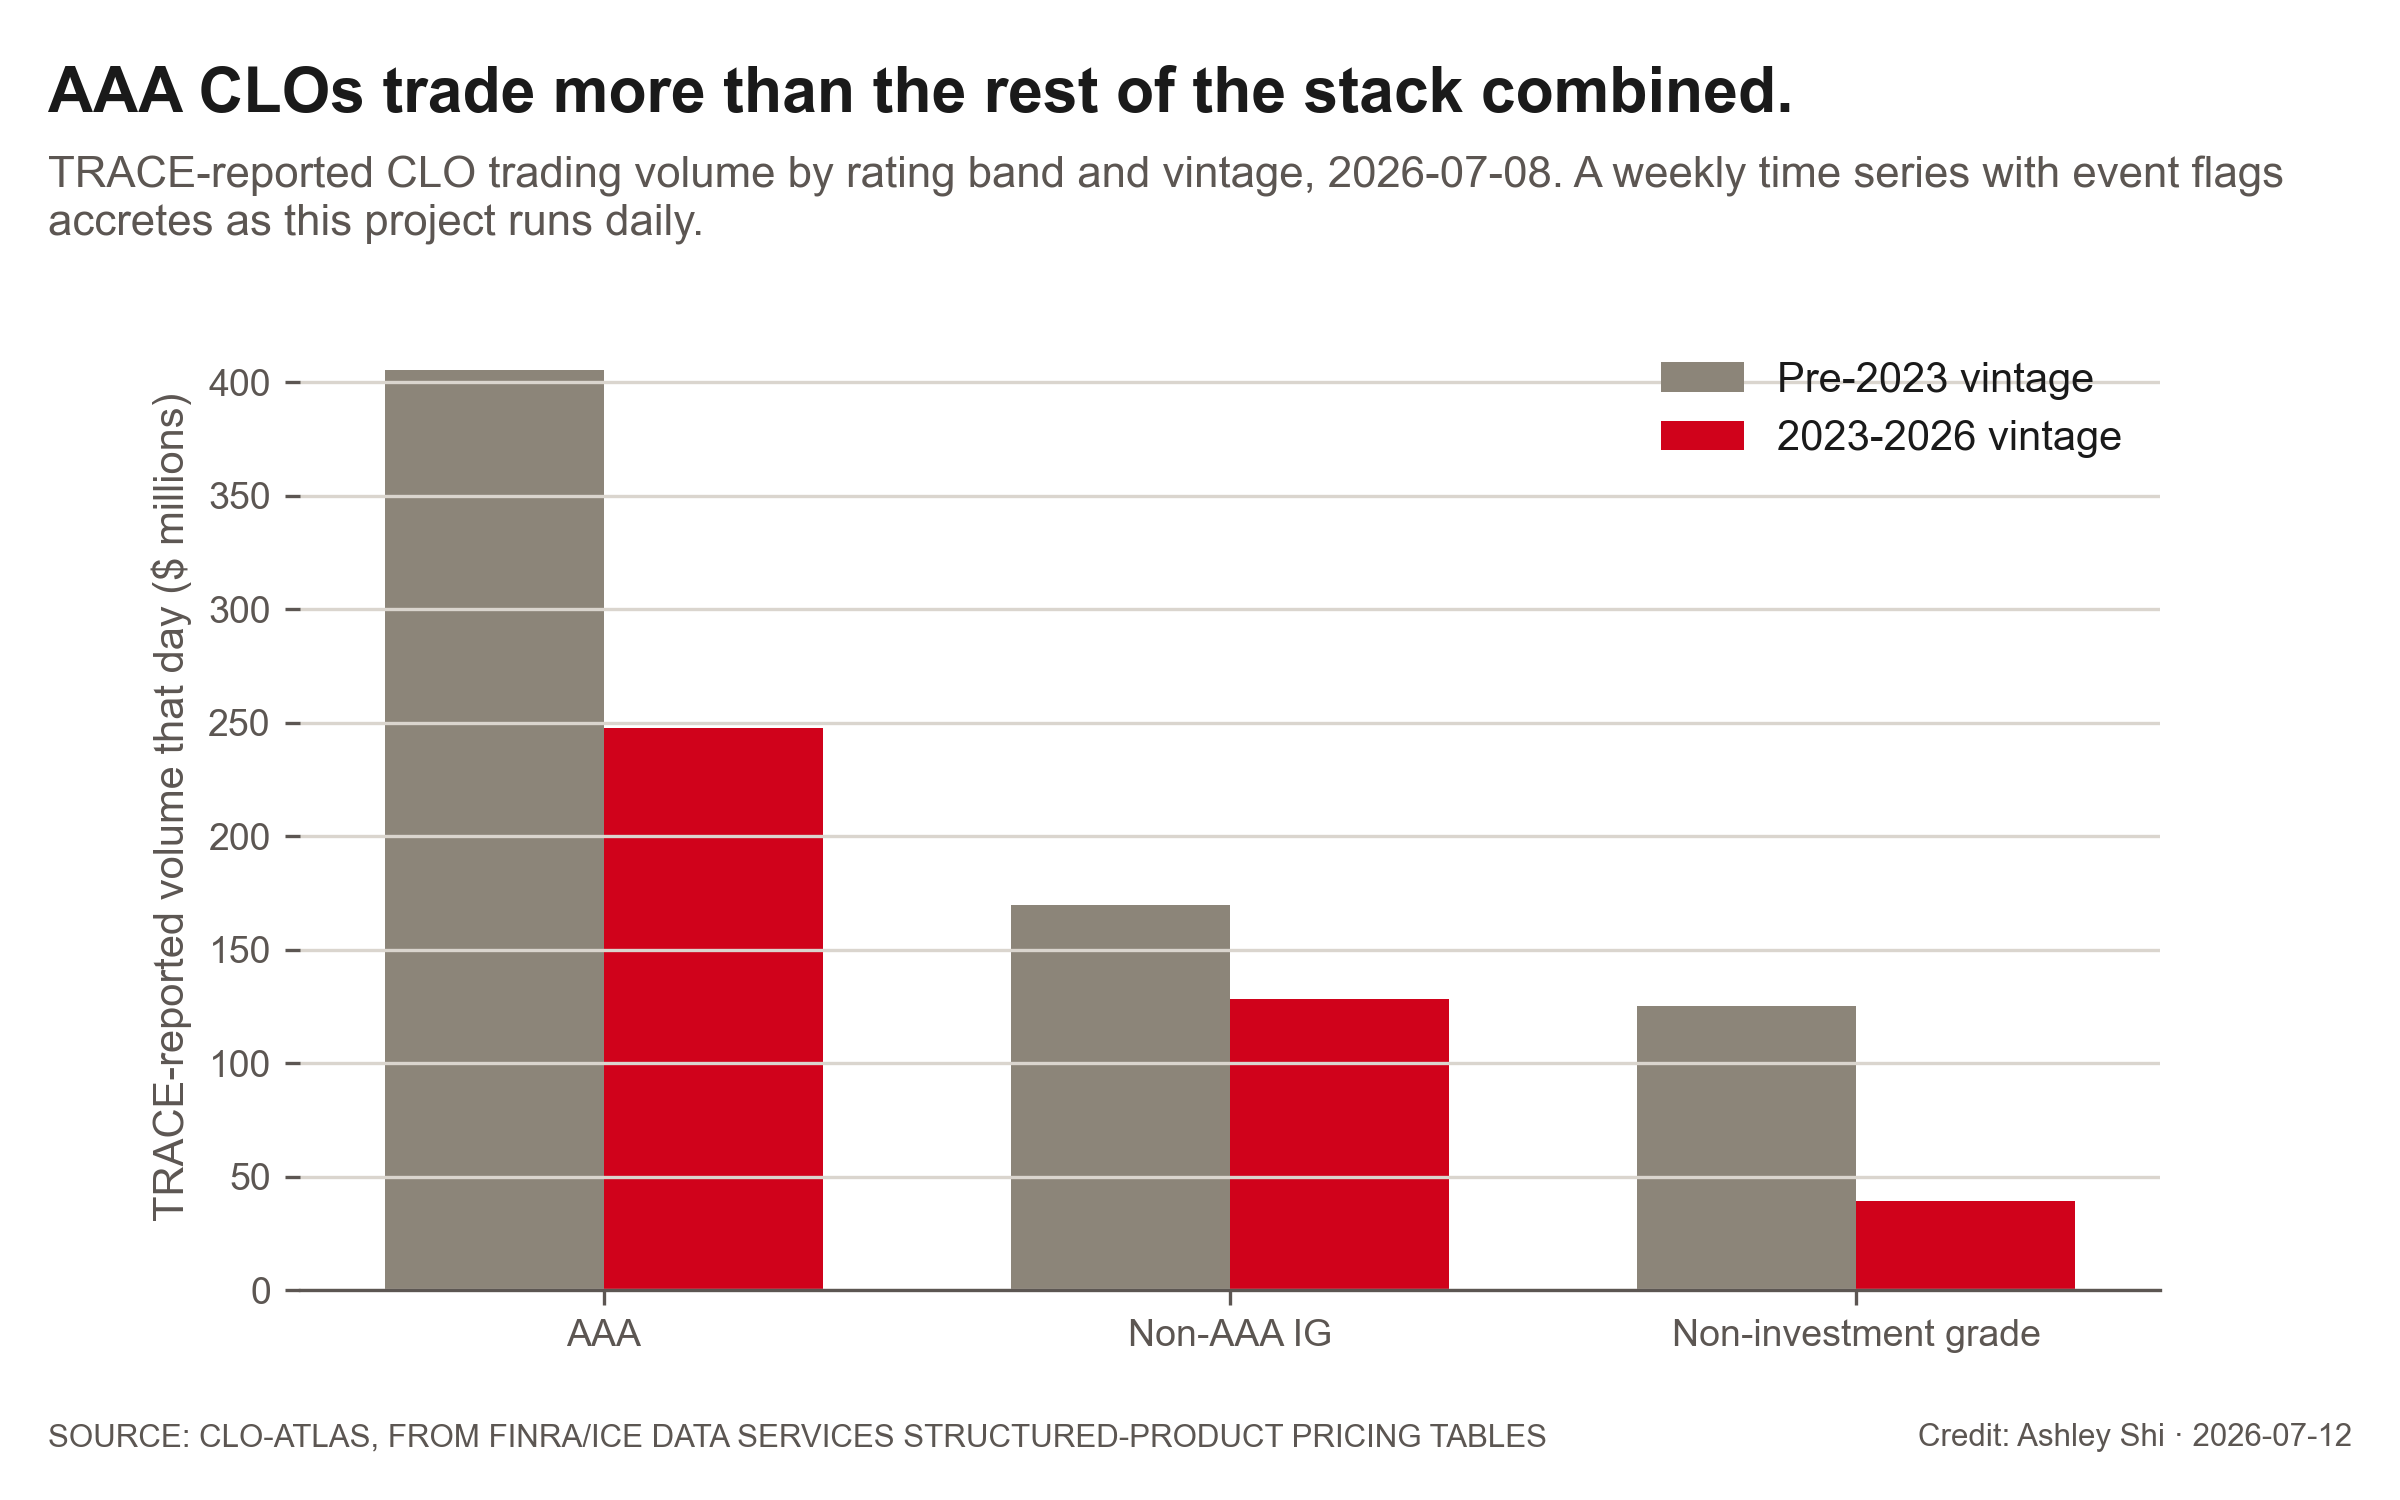

In [6]:
name = "viz_trace_volume_by_band"
path = pathlib.Path("../figures") / f"{name}.png"
if path.exists():
    display(Image(filename=str(path)))
else:
    print(f"[skipped — not generated this run] {name}")

**VERIFIED** — scraped directly from `cdn.finra.org/trace/FINRA_IDS_PXTABLES.xlsx`, FINRA/ICE Data Services' TRACE-derived structured-product pricing table (`src/official/scrape_trace.py`, unauthenticated download, verified 2026-07-09) — the closest free public proxy for FINRA TRACE CLO secondary-market trading data.

The grouped bars show that day's TRACE-reported trading volume ($ millions) across three rating bands — AAA, non-AAA investment grade, and non-investment grade — split by vintage (pre-2023 vs. 2023-2026 deals) for the most recent date in the cache.

On the day captured here, AAA volume clears the other two bands combined, and pre-2023 vintage paper out-trades the newer 2023-2026 cohort in every band — a single day's snapshot the project is designed to grow into a real weekly time series as the daily scrape accumulates history.

This is the “how it trades” half of the official-sector story: secondary-market liquidity concentrates in the safest, most seasoned tranches, the opposite of what you'd expect from an illiquid, buy-and-hold-only product.

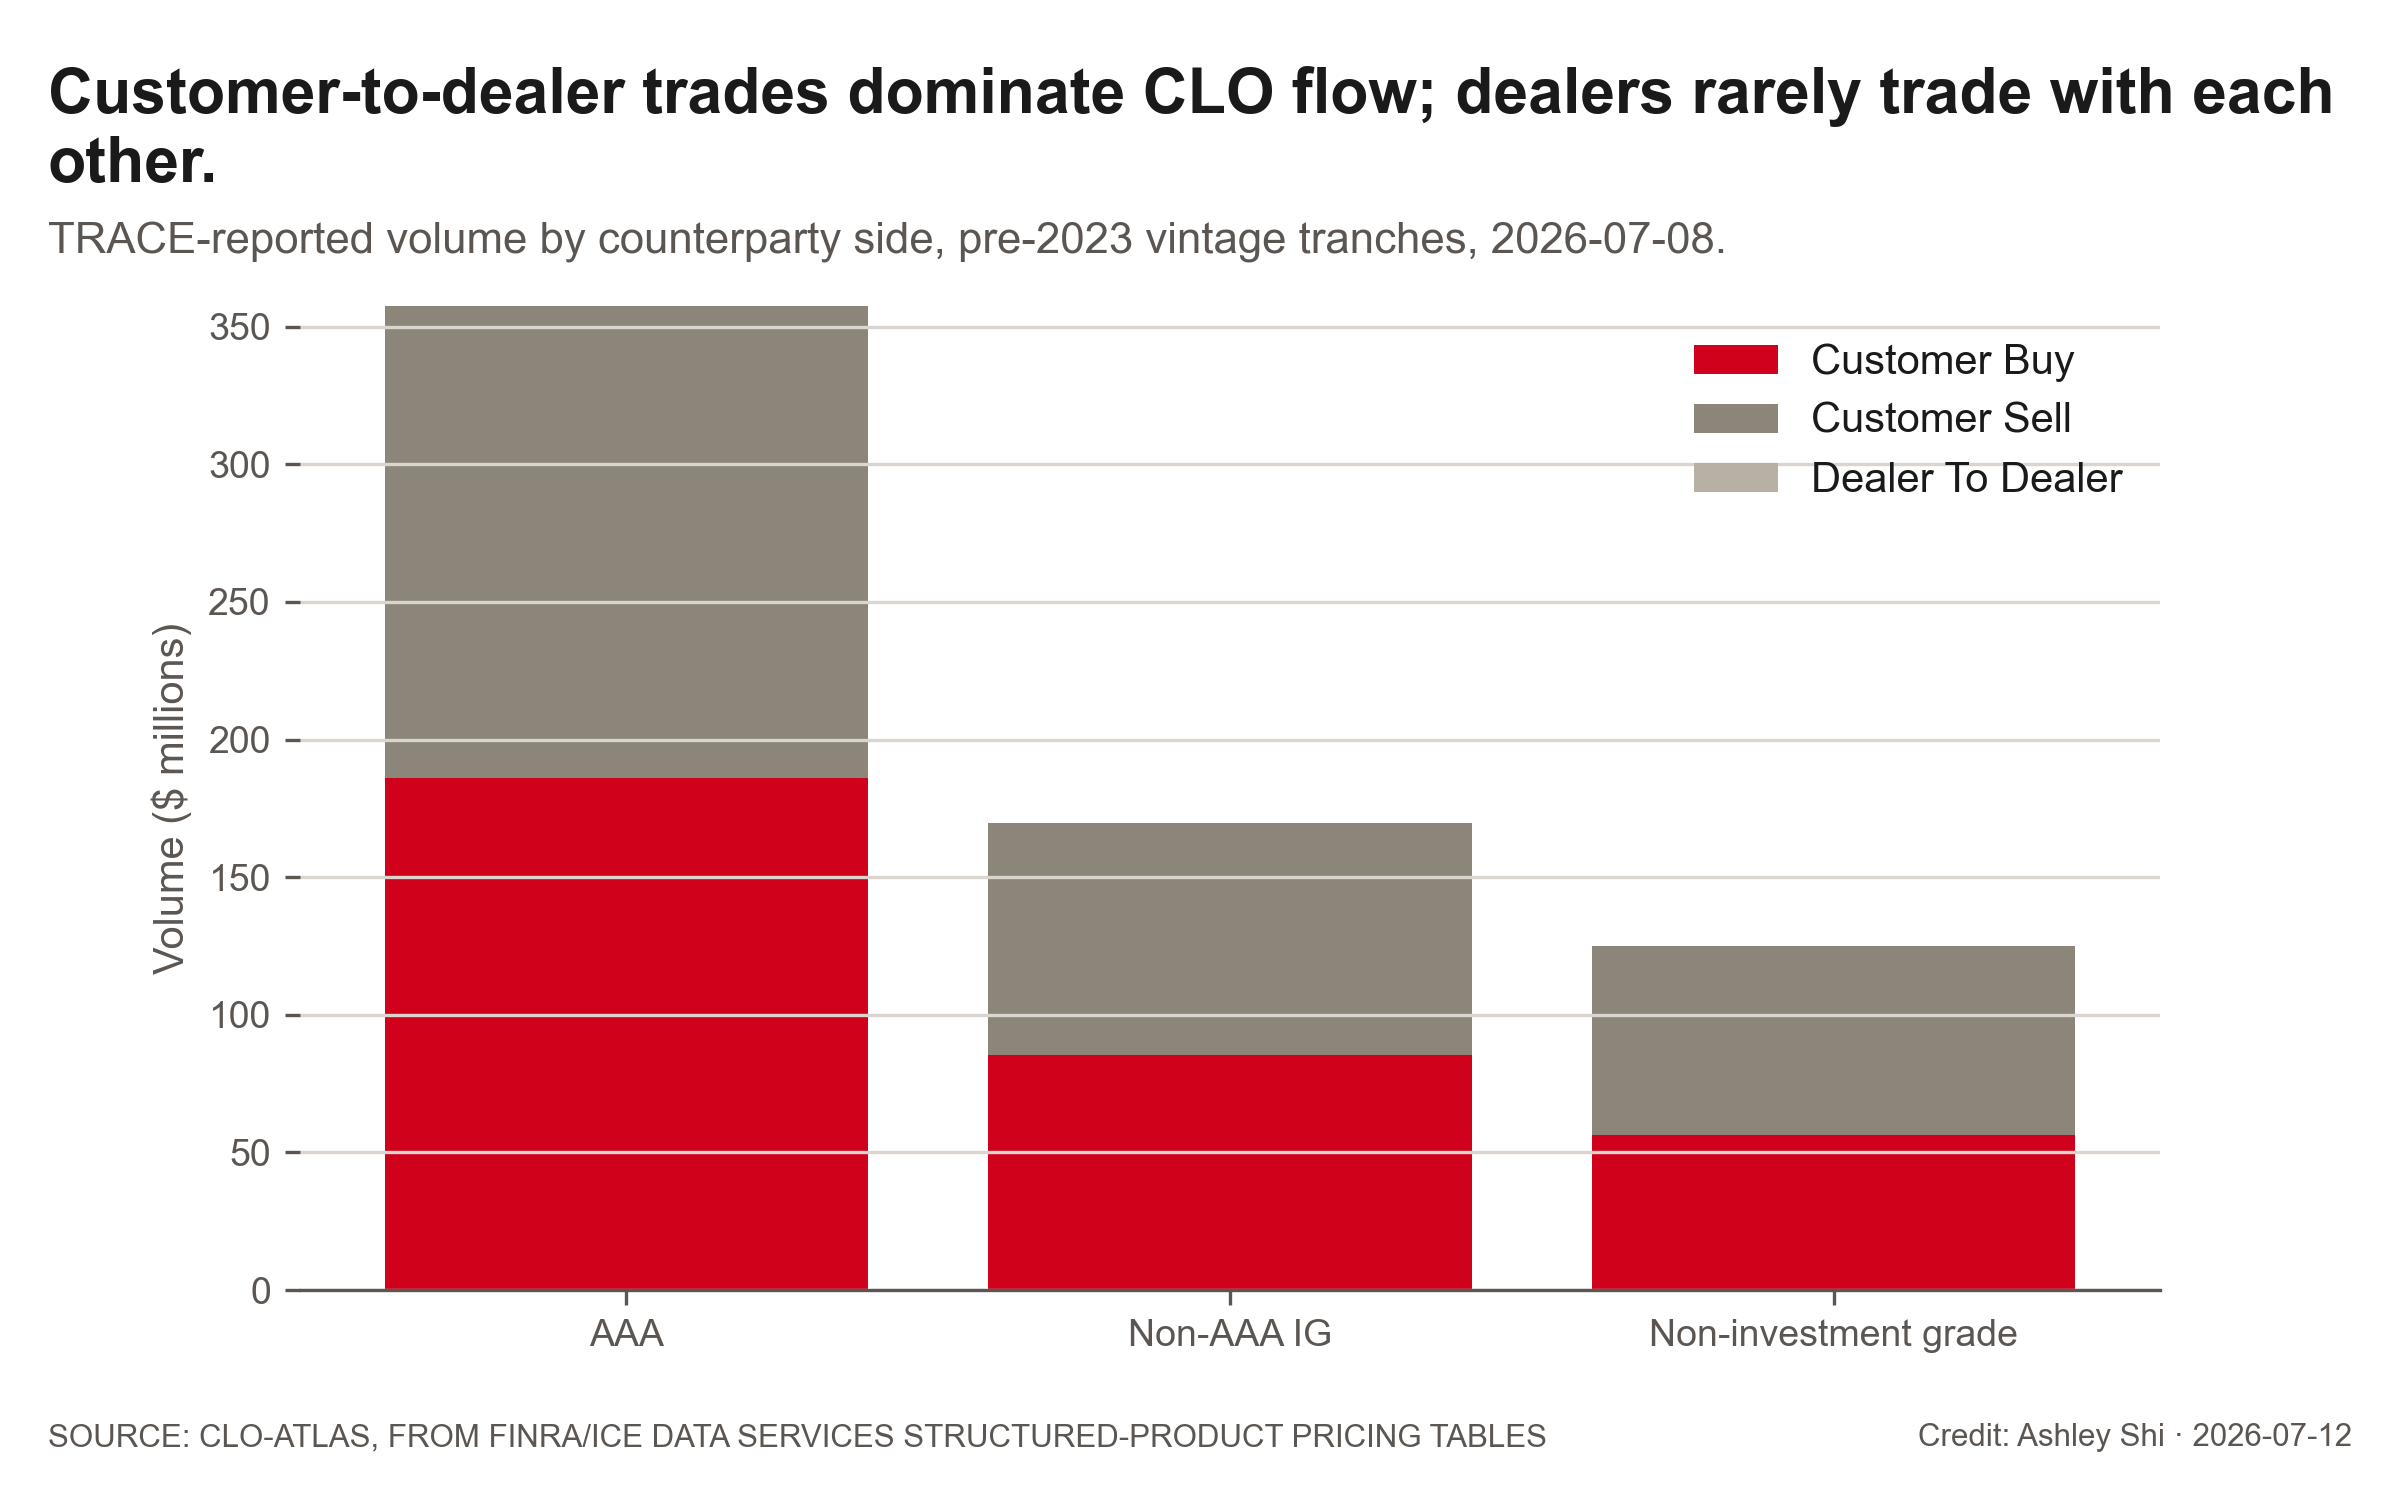

In [7]:
name = "viz_dealer_customer_split"
path = pathlib.Path("../figures") / f"{name}.png"
if path.exists():
    display(Image(filename=str(path)))
else:
    print(f"[skipped — not generated this run] {name}")

**VERIFIED** — same source as the volume-by-band chart: FINRA/ICE Data Services' TRACE-derived pricing table, scraped fresh each run via `src/official/scrape_trace.py`.

The stacked bars break that same day's pre-2023-vintage volume into three counterparty sides — customer buy, customer sell, and dealer-to-dealer — across the same three rating bands.

Customer buy and customer sell volumes run close to even in every band, while dealer-to-dealer volume is effectively zero: dealers are passing paper straight through to end investors rather than warehousing it or trading among themselves.

That's the market-plumbing payoff of this exhibit — CLO secondary trading looks like a classic customer-facilitation dealer market, not an interdealer one, which matters for how much liquidity risk sits with dealers versus end holders when conditions turn.